# K-means clustering
---
K-Means is a popular unsupervised machine learning algorithm that partitions data into
 distinct, non-overlapping clusters by minimizing the distance between data points and their cluster centroids. It iteratively assigns points to the nearest center and recalculates centroids until convergence. It is widely used for pattern discovery and customer segmentation.

Source link: https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/

In [42]:
from cProfile import label
from tarfile import data_filter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans

from sklearn.cluster import KMeans

In [43]:
data = pd.read_csv('../dataset/pca_matrix.csv')
data

,0,1,2,3,4,5,6
0,-1.696395,-1.122584,-0.491562,0.719521,-0.079830,-0.118234,0.808993
1,-1.215681,2.435638,-0.694658,-0.098843,-0.803019,0.917777,-0.322969
2,0.935853,-0.385202,0.025953,1.293844,1.987285,0.682139,-1.624721
3,-1.614638,-0.724586,-0.272358,1.086116,0.427814,-0.082982,0.687001
4,0.223701,-0.783610,1.184434,0.721353,-0.801243,-0.525879,0.788893
...,...,...,...,...,...,...,...
8631,-2.221637,-1.328411,-1.643826,-1.421354,0.175573,-3.518499,-1.313848
8632,-0.362326,-2.032249,0.875053,-2.800940,0.313566,-2.808854,-1.549426
8633,-0.930026,-1.841236,0.350037,-2.351591,0.219492,-3.090269,-1.421757
8634,-2.356010,-0.718730,-1.048522,-1.776467,0.552690,-3.333452,-0.996810


In [44]:
df_original = pd.read_csv('../dataset/cleaned_data.csv')
df_original

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


For each value of
`k` from 1 to 10, a K-Means model is trained on the dataset. The algorithm computes the within-cluster sum of squares (inertia), which measures how close the data points are to their assigned cluster centroids.

The inertia values are stored and then plotted against the number of clusters. As the number of clusters increases, inertia decreases because the clusters become more compact.

The optimal number of clusters is typically chosen at the “elbow point”, where the decrease in inertia begins to slow down significantly. This point indicates a good balance between model complexity and clustering performance.

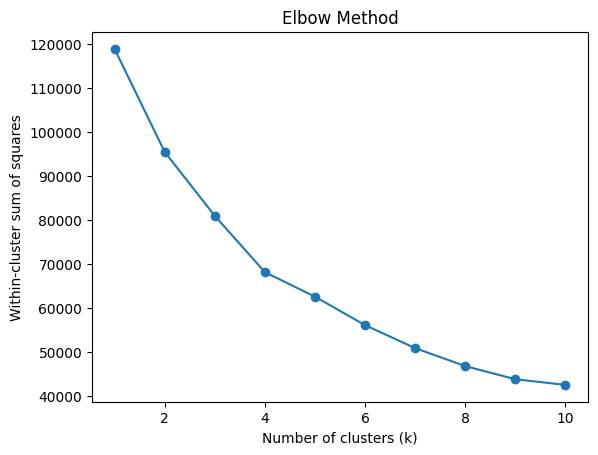

In [45]:
inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=43)
    model.fit(data)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method")
plt.show()

## K-means objective function
---
- Goal: The primary objective is to minimize the sum of squared distances between data points and their assigned cluster centroid
- Formula:

$$\LARGE
\Large
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

Where:

- $\LARGE K$ — number of clusters
- $\LARGE C_k$ — set of observations that belong to cluster $k$
- $\LARGE x_i$ — data point (observation)
- $\LARGE \mu_k$ — centroid (mean vector) of cluster $k$

- WCSS (Within-Cluster Sum of Squares): This is another term for the objective function.
- Convergence: The algorithm decreases the objective function at each iteration, guaranteeing convergence to a local optimum.
- Sensitivity: It is sensitive to initial centroid placement, which can affect the final clustering results.
- Assumptions: It assumes spherical, equally sized clusters.

#### Steps Involved in Minimizing the Objective Function:
- Initialize: Choose `k` initial centroids;
- Assignment Step: Assign each data point to the closest centroid;
- Update Step: Recompute the centroids based on the new, updated clusters;
- Repeat: Continue steps 2 and 3 until the centroids no longer change;


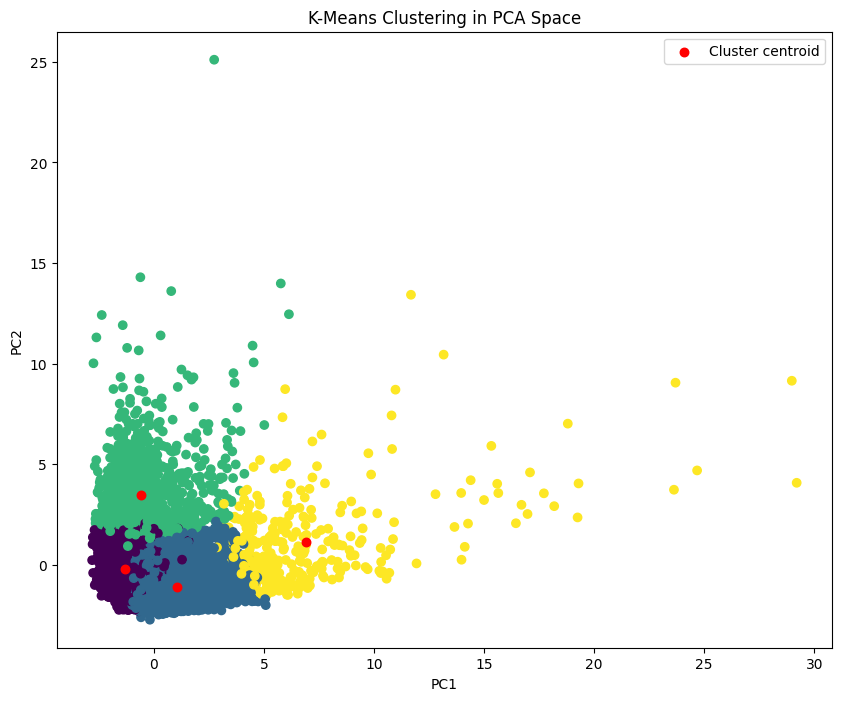

In [46]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=43)

clusters = kmeans.fit_predict(data)

data["cluster"] = clusters

plt.figure(figsize=(10, 8))

plt.scatter(
    data["0"],
    data["1"],
    c=data["cluster"]
)

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color="red",
    s=150,
    marker=".",
    label='Cluster centroid'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("K-Means Clustering in PCA Space")

plt.show()

### Cluster Centroids

The centroids of the clusters represent the central points of each cluster in the PCA-transformed feature space.

Each centroid has coordinates corresponding to the principal components:

$\LARGE
\mu_k = (PC_1, PC_2, PC_3, \dots, PC_p)
$

where:

- $\LARGE \mu_k$ is the centroid of cluster \( k \)

- $\large PC_1, PC_2, ..., PC_p$ are the principal components obtained from PCA

- $\LARGE p$ is the number of PCA features used in the clustering

In the `cluster_centers_` matrix:

- **rows** represent cluster centroids
- **columns** represent PCA features

In [47]:
kmeans.cluster_centers_

array([[-1.32375784, -0.22195935, -0.57313656,  0.36425038, -0.04964927,
        -0.16318878,  0.17504556],
       [ 1.05531666, -1.08883037,  0.66605377, -0.3181678 ,  0.09804576,
         0.18089495, -0.16067351],
       [-0.5662304 ,  3.47054334,  0.35080405, -0.46038936, -0.07631911,
         0.24863848, -0.27969319],
       [ 6.92323444,  1.12832179, -1.11837062,  0.50930625, -0.11999067,
        -0.75025302,  0.52395806]])

In [48]:
df_original["cluster"] = clusters

In [49]:
df_original

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,0
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,1
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0


### Cluster Feature Distribution Analysis
---

After assigning the observations to clusters using the K-Means algorithm, we analyze the **distribution of individual features inside each cluster**.

The goal of this step is to better understand the **characteristics and behavior of the clusters** by examining how the values of a specific feature are distributed among the observations belonging to each cluster.

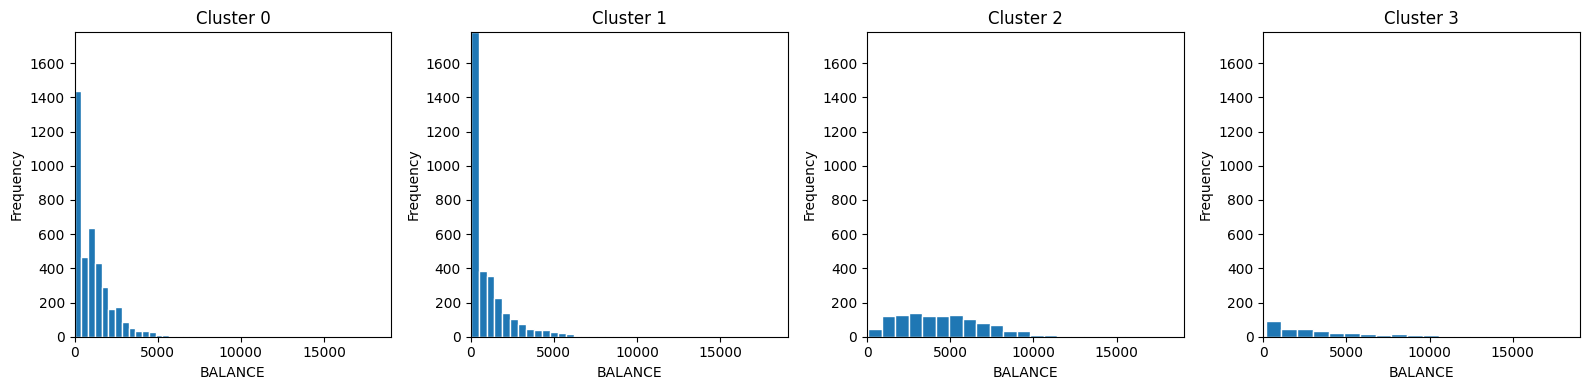

In [55]:
cluster_0 = df_original[df_original['cluster'] == 0]
cluster_1 = df_original[df_original['cluster'] == 1]
cluster_2 = df_original[df_original['cluster'] == 2]
cluster_3 = df_original[df_original['cluster'] == 3]

min_balance = df_original["BALANCE"].min()
max_balance = df_original["BALANCE"].max()

max_freq = 0
for cluster in [cluster_0, cluster_1, cluster_2, cluster_3]:
    counts, _ = np.histogram(cluster["BALANCE"], bins=20)
    max_freq = max(max_freq, counts.max())

fig, axes = plt.subplots(1, 4, figsize=(16,4))

clusters = [cluster_0, cluster_1, cluster_2, cluster_3]

for i, cluster in enumerate(clusters):

    axes[i].hist(cluster["BALANCE"], bins=20, edgecolor="white")

    axes[i].set_title(f"Cluster {i}")
    axes[i].set_xlabel("BALANCE")
    axes[i].set_ylabel("Frequency")

    axes[i].set_xlim(min_balance, max_balance)
    axes[i].set_ylim(0, max_freq)

plt.tight_layout()
plt.show()

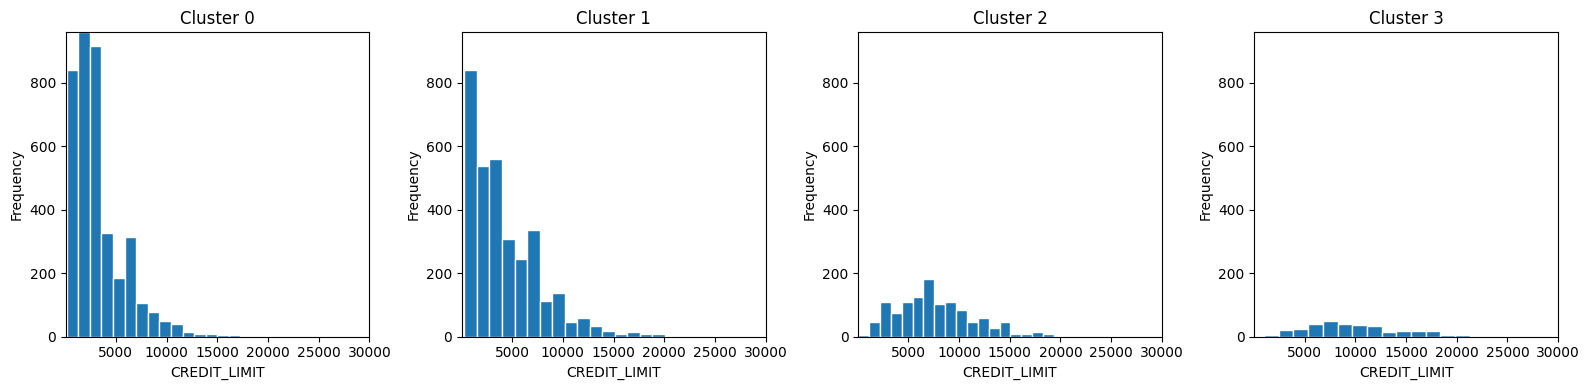

In [56]:
min_balance = df_original["CREDIT_LIMIT"].min()
max_balance = df_original["CREDIT_LIMIT"].max()

max_freq = 0
for cluster in [cluster_0, cluster_1, cluster_2, cluster_3]:
    counts, _ = np.histogram(cluster["CREDIT_LIMIT"], bins=20)
    max_freq = max(max_freq, counts.max())

fig, axes = plt.subplots(1, 4, figsize=(16,4))

clusters = [cluster_0, cluster_1, cluster_2, cluster_3]

for i, cluster in enumerate(clusters):

    axes[i].hist(cluster["CREDIT_LIMIT"], bins=20, edgecolor="white")

    axes[i].set_title(f"Cluster {i}")
    axes[i].set_xlabel("CREDIT_LIMIT")
    axes[i].set_ylabel("Frequency")

    axes[i].set_xlim(min_balance, max_balance)
    axes[i].set_ylim(0, max_freq)

plt.tight_layout()
plt.show()